<a href="https://colab.research.google.com/github/KhayalM/EFEM/blob/main/E_FEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
get_ipython().magic('reset -f')

In [ ]:
try:
    import google.colab  # noqa: F401
except ImportError:
    import gmsh
else:
    try:
        import gmsh
    except ImportError:
        !wget "https://fem-on-colab.github.io/releases/gmsh-install.sh" -O "/tmp/gmsh-install.sh" && bash "/tmp/gmsh-install.sh"
        import gmsh

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: GEOMETRY AND MATERIAL PARAMETERS
# ==========================================

# --- GEOMETRY ---
L = 0.100          # Plate side length in meters (100 mm)
thickness = 0.005  # Plate thickness in meters (5 mm)
V_f = 0.01         # Fiber volume fraction (1%)

# --- MATRIX PROPERTIES (Linear Elastic) ---
E_m = 5e9          # Young's modulus: 5 GPa (5 * 10^9 Pa)
nu_m = 0.2         # Poisson's ratio

# --- FIBER PROPERTIES (Quasi-Brittle) ---
E_f = 200e9        # Young's modulus: 200 GPa (200 * 10^9 Pa)
f_t = 400e6        # Tensile strength: 400 MPa (400 * 10^6 Pa)
G_f = 1000         # Fracture energy density: 1000 J/m^2

Generated 121 nodes and 200 CST elements.


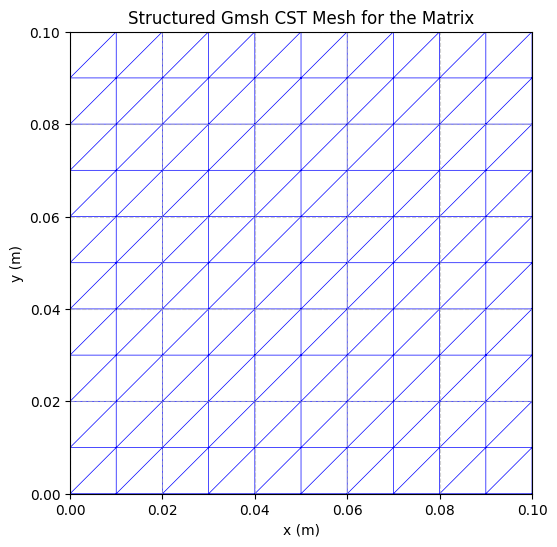

In [ ]:
# ==========================================
# STEP 2: MATRIX MESH GENERATION (GMSH)
# ==========================================

def generate_gmsh_matrix_mesh(L, lc):
    """
    Generates a STRUCTURED and UNIFORM CST mesh for a square plate using Gmsh.
    """
    if not gmsh.isInitialized():
        gmsh.initialize()
    else:
        gmsh.clear() # Clear previous models if re-running the cell

    gmsh.model.add("Square_Matrix")

    # 1. Define Geometry (L x L square)
    gmsh.model.geo.addPoint(0.0, 0.0, 0.0, lc, 1)
    gmsh.model.geo.addPoint(L,   0.0, 0.0, lc, 2)
    gmsh.model.geo.addPoint(L,   L,   0.0, lc, 3)
    gmsh.model.geo.addPoint(0.0, L,   0.0, lc, 4)

    gmsh.model.geo.addLine(1, 2, 1)
    gmsh.model.geo.addLine(2, 3, 2)
    gmsh.model.geo.addLine(3, 4, 3)
    gmsh.model.geo.addLine(4, 1, 4)

    curve_loop = gmsh.model.geo.addCurveLoop([1, 2, 3, 4])
    surface = gmsh.model.geo.addPlaneSurface([curve_loop])

    num_nodes = int(round(L / lc)) + 1

    gmsh.model.geo.mesh.setTransfiniteCurve(1, num_nodes)
    gmsh.model.geo.mesh.setTransfiniteCurve(2, num_nodes)
    gmsh.model.geo.mesh.setTransfiniteCurve(3, num_nodes)
    gmsh.model.geo.mesh.setTransfiniteCurve(4, num_nodes)

    gmsh.model.geo.mesh.setTransfiniteSurface(surface, "Right")
    # -------------------------------------------------

    gmsh.model.geo.synchronize()

    # 2. Generate Mesh
    gmsh.option.setNumber("Mesh.ElementOrder", 1)  # Linear triangles
    gmsh.model.mesh.generate(2)

    # 3. Extract Nodes (Drop Z coordinate)
    node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
    nodes = np.array(node_coords).reshape(-1, 3)[:, :2]

    # Map Gmsh tags to 0-based array indices
    tag_to_index = {tag: idx for idx, tag in enumerate(node_tags)}

    # 4. Extract Elements (Connectivity)
    _, _, node_tags_list = gmsh.model.mesh.getElements(2, surface)
    connectivity_tags = np.array(node_tags_list[0]).reshape(-1, 3)

    # Convert Gmsh tags to our 0-based node array indices
    cst_elements = np.vectorize(tag_to_index.get)(connectivity_tags)

    return nodes, cst_elements

# --- Test and Visualize the Mesh ---
mesh_size = 0.01
nodes, cst_elements = generate_gmsh_matrix_mesh(L, mesh_size)

print(f"Generated {len(nodes)} nodes and {len(cst_elements)} CST elements.")

# Plotting the mesh
plt.figure(figsize=(6, 6))
plt.triplot(nodes[:, 0], nodes[:, 1], cst_elements, color='blue', linewidth=0.5)
plt.title('Structured Gmsh CST Mesh for the Matrix')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.xlim(0, L)
plt.ylim(0, L)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# ==========================================
# STEP 3: MATRIX ELEMENT FORMULATION (CST)
# ==========================================

def get_cst_stiffness(node_coords, E, nu, thickness):
    """
    Calculates the 6x6 linear elastic stiffness matrix for a 3-node CST element
    assuming Plane Stress conditions.

    Parameters:
    node_coords : numpy array of shape (3, 2) containing [[x1,y1], [x2,y2], [x3,y3]]
    E           : Young's modulus (Pa)
    nu          : Poisson's ratio
    thickness   : Plate thickness (m)
    """
    # Extract x and y coordinates for the 3 nodes
    x1, y1 = node_coords[0, 0], node_coords[0, 1]
    x2, y2 = node_coords[1, 0], node_coords[1, 1]
    x3, y3 = node_coords[2, 0], node_coords[2, 1]

    # Calculate the Area of the triangle (A)
    A = abs(0.5 * (x1*(y2 - y3) + x2*(y3 - y1) + x3*(y1 - y2)))

    # Plane stress constitutive matrix (D)
    # This represents how the material resists strain (using E and nu)
    factor = E / (1.0 - nu**2)
    D = factor * np.array([
        [1.0,  nu,   0.0],
        [nu,  1.0,   0.0],
        [0.0, 0.0, (1.0 - nu)/2.0]
    ])

    # Strain-displacement matrix (B)
    # This relates the movement of the nodes to the strain inside the triangle
    beta1 = y2 - y3
    beta2 = y3 - y1
    beta3 = y1 - y2

    gamma1 = x3 - x2
    gamma2 = x1 - x3
    gamma3 = x2 - x1

    B = (1.0 / (2.0 * A)) * np.array([
        [beta1,   0.0, beta2,   0.0, beta3,   0.0],
        [  0.0, gamma1,   0.0, gamma2,   0.0, gamma3],
        [gamma1, beta1, gamma2, beta2, gamma3, beta3]
    ])

    # Element stiffness matrix: K_e = (B^T * D * B) * thickness * Area
    k_e = thickness * A * np.dot(B.T, np.dot(D, B))

    return k_e

# --- Test the formulation ---
test_element_nodes = cst_elements[0] # Gets the [n1, n2, n3] indices
test_coords = nodes[test_element_nodes] # Gets the actual [x,y] coordinates

k_test = get_cst_stiffness(test_coords, E_m, nu_m, thickness)

print("--- Step 3 Test Results ---")
print(f"Shape of element stiffness matrix: {k_test.shape} (Expected 6x6)")
# A valid stiffness matrix must be perfectly symmetric
print(f"Is the matrix symmetric?: {np.allclose(k_test, k_test.T)}")

--- Step 3 Test Results ---
Shape of element stiffness matrix: (6, 6) (Expected 6x6)
Is the matrix symmetric?: True


Generated 10 fibers at 30 degrees.


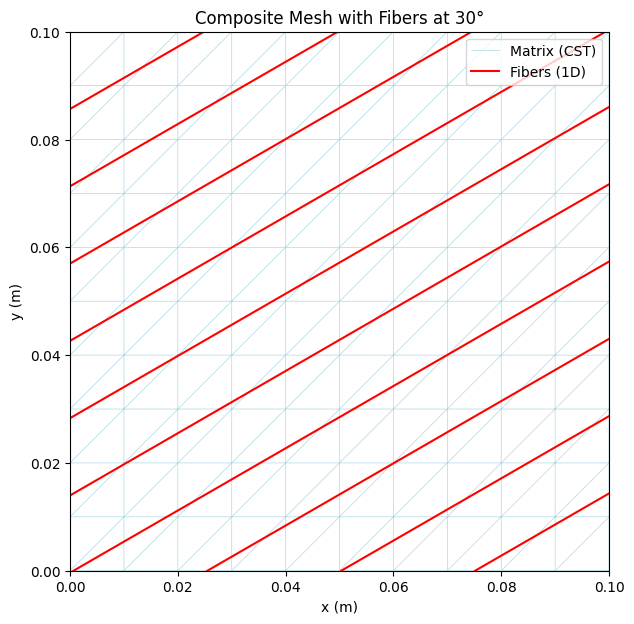

In [ ]:
# ==========================================
# STEP 4: FIBER GEOMETRY GENERATION
# ==========================================

def generate_fibers(L, angle_deg, num_fibers):
    """
    Generates parallel lines representing fibers across a square domain.

    Parameters:
    L          : Side length of the square plate (m)
    angle_deg  : Fiber orientation angle in degrees
    num_fibers : Number of fibers to distribute across the plate

    Returns:
    fibers : numpy array of shape (N, 2, 2) where each entry is [[x_start, y_start], [x_end, y_end]]
    """
    theta = np.radians(angle_deg)

    # The normal vector perpendicular to the fiber direction
    nx = -np.sin(theta)
    ny = np.cos(theta)

    # This tells us the "width" of the plate from the perspective of the fibers
    corners = np.array([[0,0], [L,0], [L,L], [0,L]])
    projections = corners[:, 0] * nx + corners[:, 1] * ny

    p_min, p_max = np.min(projections), np.max(projections)

    # Create evenly spaced points along that normal axis
    # We add +2 and slice [1:-1] to avoid putting fibers exactly on the very edges
    p_vals = np.linspace(p_min, p_max, num_fibers + 2)[1:-1]

    fibers = []
    for p in p_vals:
        pts = []
        # Find intersections with the vertical boundaries (x = 0 and x = L)
        if abs(ny) > 1e-6: # Prevent division by zero
            y0 = p / ny
            if 0 <= y0 <= L: pts.append([0.0, y0])
            yL = (p - nx * L) / ny
            if 0 <= yL <= L: pts.append([L, yL])

        # Find intersections with the horizontal boundaries (y = 0 and y = L)
        if abs(nx) > 1e-6: # Prevent division by zero
            x0 = p / nx
            if 0 <= x0 <= L: pts.append([x0, 0.0])
            xL = (p - ny * L) / nx
            if 0 <= xL <= L: pts.append([xL, L])

        # A valid line crossing the box will have exactly 2 unique intersection points
        if len(pts) >= 2:
            # We take the first two to form the line segment
            fibers.append([pts[0], pts[1]])

    return np.array(fibers)

# --- Test and Visualize the Fibers + Mesh ---
angle_test = 30
n_fibers_test = 10  # Arbitrary number of fibers for visualization

fibers_coords = generate_fibers(L, angle_test, n_fibers_test)

print(f"Generated {len(fibers_coords)} fibers at {angle_test} degrees.")

# Plot the matrix mesh AND the fibers on top
plt.figure(figsize=(7, 7))
plt.triplot(nodes[:, 0], nodes[:, 1], cst_elements, color='lightblue', linewidth=0.5, label='Matrix (CST)')

# Loop through and plot each fiber
for i, fib in enumerate(fibers_coords):
    # Only label the first one to keep the legend clean
    label = 'Fibers (1D)' if i == 0 else ""
    plt.plot([fib[0][0], fib[1][0]], [fib[0][1], fib[1][1]], color='red', linewidth=1.5, label=label)

plt.title(f'Composite Mesh with Fibers at {angle_test}°')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.xlim(0, L)
plt.ylim(0, L)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc='upper right')
plt.show()

Found 136 elements cut by fibers.


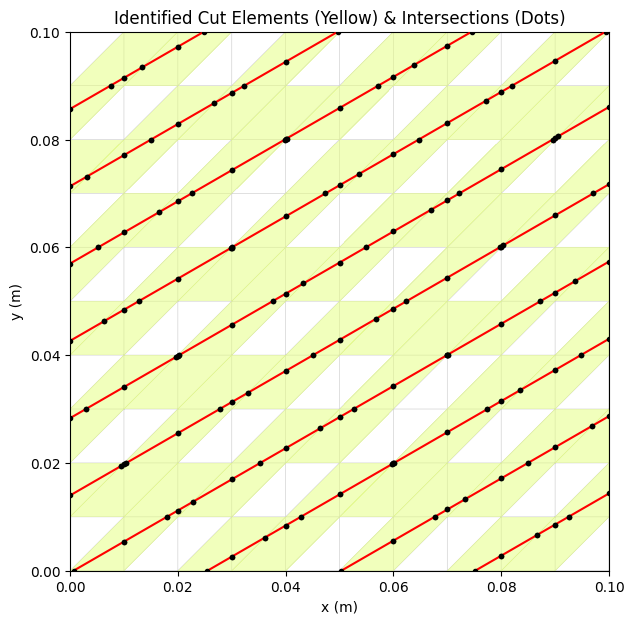

In [ ]:
# ==========================================
# STEP 5: MESH INTERSECTION (FIBERS CUTTING MATRIX)
# ==========================================

def intersect_segments(p1, p2, p3, p4):
    """
    Calculates the intersection point of two line segments.
    Updated with floating-point tolerance to prevent dropped elements!
    """
    x1, y1 = p1[0], p1[1]
    x2, y2 = p2[0], p2[1]
    x3, y3 = p3[0], p3[1]
    x4, y4 = p4[0], p4[1]

    # Denominator for the intersection formula
    den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)

    # If denominator is 0, lines are parallel
    if abs(den) < 1e-8: return None

    # Calculate parameters t and u
    t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / den
    u = -((x1 - x2) * (y1 - y3) - (y1 - y2) * (x1 - x3)) / den

    # THE FIX: Add a tiny numerical tolerance (1e-8) to the bounds
    # to catch intersections that fall exactly on triangle edges
    tol = 1e-8
    if (0.0 - tol) <= t <= (1.0 + tol) and (0.0 - tol) <= u <= (1.0 + tol):
        return np.array([x1 + t * (x2 - x1), y1 + t * (y2 - y1)])

    return None

def find_cut_elements(nodes, elements, fibers):
    """
    Identifies which CST elements are cut by fibers and finds the entry/exit points.
    """
    cut_elements = {} # Dictionary to store: {element_id: [intersection_points]}

    for el_id, el_nodes in enumerate(elements):
        # Get the coordinates of the 3 nodes of this triangle
        p1 = nodes[el_nodes[0]]
        p2 = nodes[el_nodes[1]]
        p3 = nodes[el_nodes[2]]

        # Define the 3 edges of the triangle
        edges = [(p1, p2), (p2, p3), (p3, p1)]

        for fib_id, fiber in enumerate(fibers):
            intersections = []

            # Check the fiber against all 3 edges of the triangle
            for edge in edges:
                pt = intersect_segments(fiber[0], fiber[1], edge[0], edge[1])

                if pt is not None:
                    # Check if we already found this point (to avoid corner-case duplicates)
                    is_duplicate = any(np.linalg.norm(pt - existing_pt) < 1e-6 for existing_pt in intersections)
                    if not is_duplicate:
                        intersections.append(pt)

            # A true cut through a triangle will have exactly 2 intersection points
            if len(intersections) == 2:
                cut_elements[el_id] = {
                    'fiber_id': fib_id,
                    'points': intersections,
                    'length': np.linalg.norm(intersections[0] - intersections[1]) # Length of fiber inside element
                }
                break # Move to the next element once we find a cut

    return cut_elements

# --- Test and Visualize the Intersections ---
cut_elements_info = find_cut_elements(nodes, cst_elements, fibers_coords)

print(f"Found {len(cut_elements_info)} elements cut by fibers.")

# Plot the mesh, fibers, and highlight the cut elements
plt.figure(figsize=(7, 7))

# 1. Plot all matrix elements (light gray)
plt.triplot(nodes[:, 0], nodes[:, 1], cst_elements, color='lightgray', linewidth=0.5, zorder=1)

# 2. Highlight cut elements (yellow)
cut_triangles = [cst_elements[i] for i in cut_elements_info.keys()]
if len(cut_triangles) > 0:
    # Use tripcolor to fill the cut triangles
    plt.tripcolor(nodes[:, 0], nodes[:, 1], cut_triangles, facecolors=np.ones(len(cut_triangles)), cmap='Wistia', alpha=0.5, zorder=2)

# 3. Plot fibers (red)
for fib in fibers_coords:
    plt.plot([fib[0][0], fib[1][0]], [fib[0][1], fib[1][1]], color='red', linewidth=1.5, zorder=3)

# 4. Plot the exact intersection points (black dots)
for info in cut_elements_info.values():
    pts = info['points']
    plt.plot([pts[0][0], pts[1][0]], [pts[0][1], pts[1][1]], 'ko', markersize=3, zorder=4)

plt.title('Identified Cut Elements (Yellow) & Intersections (Dots)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.xlim(0, L)
plt.ylim(0, L)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [ ]:
# ==========================================
# STEP 6: BOUNDARY CONDITIONS (MPC TRANSFORMATION)
# ==========================================
import scipy.sparse as sp
import numpy as np

def get_boundary_conditions_MPC(nodes, L, kappa):
    """
    Applies pure bending using a Multi-Point Constraint (MPC) approach.
    Forces the right edge to rotate by kappa, but allows the entire edge
    to translate horizontally (u_0) to maintain Sum(F_x) = 0.
    """
    total_dofs = len(nodes) * 2
    y_NA_geom = L / 2.0

    left_nodes = [i for i, (x, y) in enumerate(nodes) if abs(x) < 1e-6]
    pin_node_idx = min(left_nodes, key=lambda i: abs(nodes[i][1] - y_NA_geom))

    U_prescribed = np.zeros(total_dofs)
    T_rows, T_cols, T_vals = [], [], []

    reduced_dof_counter = 0
    right_edge_x_dofs = []

    # 1. First pass: Identify right edge DOFs
    for i, (x, y) in enumerate(nodes):
        if abs(x - L) < 1e-6:
            right_edge_x_dofs.append(2 * i)

    # 2. Assign standard free DOFs
    for i, (x, y) in enumerate(nodes):
        dof_x = 2 * i
        dof_y = 2 * i + 1

        # --- X DOFS ---
        if abs(x) < 1e-6:
            pass # Left edge fixed at 0 (No column in T)
        elif abs(x - L) < 1e-6:
            # Right edge: Set the prescribed curvature portion
            U_prescribed[dof_x] = -kappa * L * (y - y_NA_geom)
        else:
            # Normal Free X DOF
            T_rows.append(dof_x); T_cols.append(reduced_dof_counter); T_vals.append(1.0)
            reduced_dof_counter += 1

        # --- Y DOFS ---
        if i == pin_node_idx:
            pass # Pinned node fixed at 0 (No column in T)
        else:
            # All other Y DOFS are free
            T_rows.append(dof_y); T_cols.append(reduced_dof_counter); T_vals.append(1.0)
            reduced_dof_counter += 1

    # 3. Master Node for Right Edge Translation (u_0)
    u0_dof_index = reduced_dof_counter
    num_reduced_dofs = reduced_dof_counter + 1

    # Link all right edge X-DOFs to this single master variable (u_0)
    for dof_x in right_edge_x_dofs:
        T_rows.append(dof_x); T_cols.append(u0_dof_index); T_vals.append(1.0)

    # Build Sparse Transformation Matrix
    T_matrix = sp.csr_matrix((T_vals, (T_rows, T_cols)), shape=(total_dofs, num_reduced_dofs))

    return T_matrix, U_prescribed

# --- Test the Boundary Conditions ---
# Let's test with a small curvature of 0.1 (1/m)
test_kappa = 0.1
T_mat, U_pre = get_boundary_conditions_MPC(nodes, L, test_kappa)

print("--- Boundary Conditions Applied (MPC) ---")
print(f"Total Degrees of Freedom (DOFs) in the global mesh: {len(nodes) * 2}")
print(f"Reduced DOFs for Solver (after constraints): {T_mat.shape[1]}")

# Let's peek at the prescribed displacements on the right edge
print("\nSample PRESCRIBED displacements on the right edge (x = L):")
print("(Note: The final displacement will be this value + the solved uniform translation u_0)")
for node_idx, (x, y) in enumerate(nodes):
    if abs(x - L) < 1e-6:
        dof_x = 2 * node_idx
        disp = U_pre[dof_x]

        # Formatting to show millimeters for readability
        print(f"  At y = {y:.3f} m -> Prescribed Rotational part: {disp * 1000:.3f} mm")

--- Boundary Conditions Applied (MPC) ---
Total Degrees of Freedom (DOFs) in the global mesh: 242
Reduced DOFs for Solver (after constraints): 220

Sample PRESCRIBED displacements on the right edge (x = L):
(Note: The final displacement will be this value + the solved uniform translation u_0)
  At y = 0.000 m -> Prescribed Rotational part: 0.500 mm
  At y = 0.100 m -> Prescribed Rotational part: -0.500 mm
  At y = 0.010 m -> Prescribed Rotational part: 0.400 mm
  At y = 0.020 m -> Prescribed Rotational part: 0.300 mm
  At y = 0.030 m -> Prescribed Rotational part: 0.200 mm
  At y = 0.040 m -> Prescribed Rotational part: 0.100 mm
  At y = 0.050 m -> Prescribed Rotational part: 0.000 mm
  At y = 0.060 m -> Prescribed Rotational part: -0.100 mm
  At y = 0.070 m -> Prescribed Rotational part: -0.200 mm
  At y = 0.080 m -> Prescribed Rotational part: -0.300 mm
  At y = 0.090 m -> Prescribed Rotational part: -0.400 mm


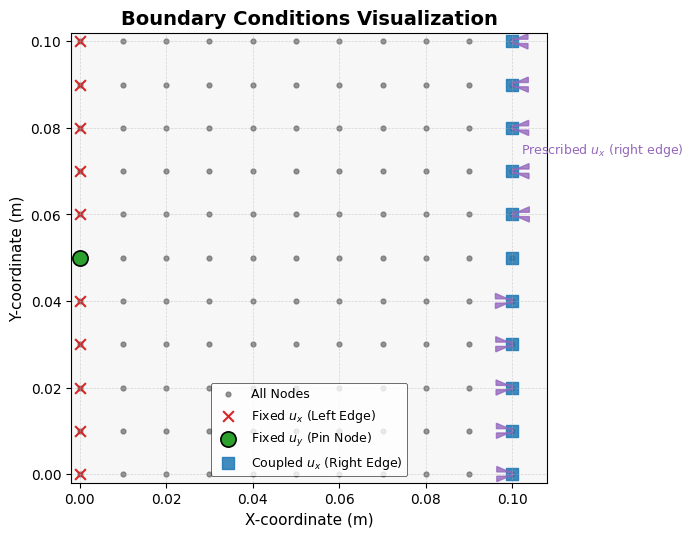

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Visualization of Boundary Conditions ---

test_kappa = 0.1
T_mat, U_pre = get_boundary_conditions_MPC(nodes, L, test_kappa)

x_coords = nodes[:, 0]
y_coords = nodes[:, 1]

# --- Figure setup ---
plt.figure(figsize=(7, 7))
ax = plt.gca()
ax.set_facecolor('#f7f7f7')

# --- All nodes ---
plt.scatter(x_coords, y_coords,
            s=12, c='dimgray', alpha=0.7,
            label='All Nodes')

# --- Left edge (fixed Dx) ---
fixed_x_nodes_idx = [i for i, (x, y) in enumerate(nodes) if abs(x) < 1e-6]
fixed_x_coords = nodes[fixed_x_nodes_idx]

plt.scatter(fixed_x_coords[:, 0], fixed_x_coords[:, 1],
            s=60, c='#d62728', marker='x',
            linewidths=1.5,
            label='Fixed $u_x$ (Left Edge)')

# --- Pin node (fixed Dy) ---
y_NA_geom = L / 2.0
pin_node_idx = min(fixed_x_nodes_idx, key=lambda i: abs(nodes[i][1] - y_NA_geom))
pin_node_coords = nodes[pin_node_idx]

plt.scatter(pin_node_coords[0], pin_node_coords[1],
            s=120, c='#2ca02c', marker='o',
            edgecolors='black', linewidth=1.2,
            zorder=5,
            label='Fixed $u_y$ (Pin Node)')

# --- Right edge (coupled Dx) ---
right_edge_x_nodes_idx = [i for i, (x, y) in enumerate(nodes) if abs(x - L) < 1e-6]
right_edge_x_coords = nodes[right_edge_x_nodes_idx]

plt.scatter(right_edge_x_coords[:, 0], right_edge_x_coords[:, 1],
            s=70, c='#1f77b4', marker='s',
            alpha=0.85,
            label='Coupled $u_x$ (Right Edge)')

# --- Displacement arrows ---
scale_factor_disp = 1.0
arrow_scale = 0.8  # visual tuning

for node_idx in right_edge_x_nodes_idx:
    dof_x = 2 * node_idx
    if abs(U_pre[dof_x]) > 1e-10:
        plt.arrow(nodes[node_idx, 0], nodes[node_idx, 1],
                  U_pre[dof_x] * arrow_scale, 0,
                  head_width=0.0035,
                  head_length=0.004,
                  fc='#9467bd', ec='#9467bd',
                  alpha=0.8,
                  length_includes_head=True)

# --- Annotation ---
plt.text(L * 1.02, L * 0.75,
         f'Prescribed $u_x$ (right edge)',
         color='#9467bd',
         fontsize=9,
         verticalalignment='center')

# --- Axes formatting ---
plt.title('Boundary Conditions Visualization', fontsize=14, weight='bold')
plt.xlabel('X-coordinate (m)', fontsize=11)
plt.ylabel('Y-coordinate (m)', fontsize=11)

plt.xlim(-0.02 * L, 1.08 * L)
plt.ylim(-0.02 * L, 1.02 * L)

ax.set_aspect('equal', adjustable='box')

# --- Grid ---
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# --- Legend cleanup ---
legend = plt.legend(frameon=True, fontsize=9)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.5)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# STEP 7: GLOBAL ASSEMBLY (MATRIX STIFFNESS)
# ==========================================
from scipy.sparse import lil_matrix

def assemble_global_stiffness(nodes, elements, E, nu, thickness):
    """
    Assembles the global stiffness matrix for the linear elastic matrix material.

    Parameters:
    nodes     : Array of nodal coordinates
    elements  : Array of CST element connectivities
    E, nu     : Young's modulus and Poisson's ratio
    thickness : Plate thickness

    Returns:
    K_global  : Scipy CSR sparse matrix representing the global stiffness
    """
    num_nodes = len(nodes)
    total_dofs = 2 * num_nodes

    # We use LIL (List of Lists) format initially because it's very fast
    # for adding items into a sparse matrix one by one.
    K_global = lil_matrix((total_dofs, total_dofs))

    for el_nodes in elements:
        # 1. Get the coordinates of the element's 3 nodes
        coords = nodes[el_nodes]

        # 2. Calculate the local 6x6 stiffness matrix (using our function from Step 3)
        k_local = get_cst_stiffness(coords, E, nu, thickness)

        # 3. Determine the global Degree of Freedom (DOF) indices for these 3 nodes
        # Node 0: x-disp -> 2*n0, y-disp -> 2*n0 + 1
        # Node 1: x-disp -> 2*n1, y-disp -> 2*n1 + 1
        # Node 2: x-disp -> 2*n2, y-disp -> 2*n2 + 1
        global_dofs = [
            2 * el_nodes[0], 2 * el_nodes[0] + 1,
            2 * el_nodes[1], 2 * el_nodes[1] + 1,
            2 * el_nodes[2], 2 * el_nodes[2] + 1
        ]

        # 4. Add the local stiffness values into the correct spots in the global matrix
        for i in range(6):
            for j in range(6):
                K_global[global_dofs[i], global_dofs[j]] += k_local[i, j]

    # Convert to CSR (Compressed Sparse Row) format.
    # It's much faster for solving the actual math equations later.
    return K_global.tocsr()

# --- Test the Assembly ---
K_matrix_global = assemble_global_stiffness(nodes, cst_elements, E_m, nu_m, thickness)

print("--- Step 7 Assembly Results ---")
print(f"Shape of Global Stiffness Matrix: {K_matrix_global.shape}")
print(f"Number of non-zero entries (Sparsity): {K_matrix_global.nnz}")
print(f"Percentage of matrix filled: {(K_matrix_global.nnz / (K_matrix_global.shape[0]**2)) * 100:.2f}%")

--- Step 7 Assembly Results ---
Shape of Global Stiffness Matrix: (242, 242)
Number of non-zero entries (Sparsity): 3044
Percentage of matrix filled: 5.20%


In [ ]:
# ==========================================
# STEP 8: THE LINEAR SOLVER & REACTION FORCES
# ==========================================
from scipy.sparse.linalg import spsolve
import scipy.sparse as sp

# ==========================================
# STEP 8: THE LINEAR SOLVER & REACTION FORCES
# ==========================================
from scipy.sparse.linalg import spsolve

def solve_linear_system_MPC(K_global, T_matrix, U_prescribed):
    """
    Solves the linear system using the MPC Transformation Matrix.
    K_reduced = T^T * K * T
    """
    # 1. Reduce the stiffness matrix
    K_reduced = T_matrix.T.dot(K_global.dot(T_matrix))

    # 2. Reduce the force vector (F_ext is 0, so it's just the prescribed part)
    F_reduced = T_matrix.T.dot(-K_global.dot(U_prescribed))

    # 3. Solve for the reduced DOFs (which includes our master translation u_0)
    U_reduced = spsolve(K_reduced, F_reduced)

    # 4. Expand back to the full global displacements
    U_full = T_matrix.dot(U_reduced) + U_prescribed

    # 5. Calculate Reaction Forces
    R_full = K_global.dot(U_full)

    return U_full, R_full

def calculate_bending_moment(nodes, R, L):
    """
    Calculates the macroscopic bending moment from reaction forces on the right edge.
    """
    y_NA = L / 2.0
    moment = 0.0

    for i, (x, y) in enumerate(nodes):
        # Check if node is on the right edge
        if abs(x - L) < 1e-6:
            dof_x = 2 * i
            reaction_force_x = R[dof_x]

            # Moment = Force * Lever Arm (distance from neutral axis)
            # The negative sign ensures standard sign convention (positive curvature = positive moment)
            moment += -reaction_force_x * (y - y_NA)

    return moment

# --- Test the Solver ---
# We will use the K_matrix_global and bc_dict we generated in Steps 6 & 7
U_global, Reactions = solve_linear_system_MPC(K_matrix_global, T_mat, U_pre)
M_matrix_only = calculate_bending_moment(nodes, Reactions, L)

print("--- Step 8 Solver Results ---")
print(f"Max horizontal displacement: {np.max(np.abs(U_global[0::2])) * 1000:.3f} mm")
print(f"Max vertical displacement: {np.max(np.abs(U_global[1::2])) * 1000:.3f} mm")
print(f"Calculated Bending Moment (Pure Matrix): {M_matrix_only:.2f} N.m")

--- Step 8 Solver Results ---
Max horizontal displacement: 0.500 mm
Max vertical displacement: 0.530 mm
Calculated Bending Moment (Pure Matrix): 215.28 N.m


In [ ]:
# ==========================================
# STEP 9: EMBEDDING FIBERS (ELASTIC COMPOSITE)
# ==========================================

def get_shape_functions(coords, pt):
    """
    Calculates the shape functions (N1, N2, N3) for a point inside a triangle
    using area coordinates. This is bulletproof regardless of node order.
    """
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]
    x, y = pt

    def tri_area(xa, ya, xb, yb, xc, yc):
        return 0.5 * abs(xa*(yb-yc) + xb*(yc-ya) + xc*(ya-yb))

    A = tri_area(x1, y1, x2, y2, x3, y3)

    # Area of sub-triangles opposite to each node
    A1 = tri_area(x, y, x2, y2, x3, y3)
    A2 = tri_area(x1, y1, x, y, x3, y3)
    A3 = tri_area(x1, y1, x2, y2, x, y)

    return A1/A, A2/A, A3/A

def assemble_composite_stiffness(nodes, elements, cut_elements_info, L, thickness, V_f, E_m, nu_m, E_f):
    """
    Assembles the global stiffness matrix combining BOTH the matrix and the embedded fibers.
    """
    num_nodes = len(nodes)
    total_dofs = 2 * num_nodes
    K_global = sp.lil_matrix((total_dofs, total_dofs))

    # --- 1. Calculate the Cross-Sectional Area of a single fiber (A_f) ---
    total_plate_volume = L * L * thickness
    total_fiber_volume = V_f * total_plate_volume
    total_fiber_length = sum(info['length'] for info in cut_elements_info.values())

    # To avoid division by zero if no fibers are in the mesh (e.g., V_f = 0)
    A_f = total_fiber_volume / total_fiber_length if total_fiber_length > 0 else 0.0

    # --- 2. Assemble the Global Matrix ---
    for el_id, el_nodes in enumerate(elements):
        coords = nodes[el_nodes]

        # Get the standard matrix stiffness (Step 3)
        k_local = get_cst_stiffness(coords, E_m, nu_m, thickness)

        # --- ADD FIBER STIFFNESS IF THIS ELEMENT IS CUT ---
        if el_id in cut_elements_info:
            info = cut_elements_info[el_id]
            p1, p2 = info['points'][0], info['points'][1]
            L_seg = info['length']

            # Fiber Direction Cosines
            c = (p2[0] - p1[0]) / L_seg
            s = (p2[1] - p1[1]) / L_seg

            # 1D Truss Local Stiffness Matrix (4x4)
            k_truss = (E_f * A_f / L_seg) * np.array([
                [ c**2,  c*s, -c**2, -c*s],
                [ c*s,  s**2, -c*s, -s**2],
                [-c**2, -c*s,  c**2,  c*s],
                [-c*s, -s**2,  c*s,  s**2]
            ])

            # Interpolation Matrix (H): Maps the 4 fiber DOFs to the 6 triangle DOFs
            N1_1, N2_1, N3_1 = get_shape_functions(coords, p1)
            N1_2, N2_2, N3_2 = get_shape_functions(coords, p2)

            H = np.array([
                [N1_1,  0.0, N2_1,  0.0, N3_1,  0.0],
                [ 0.0, N1_1,  0.0, N2_1,  0.0, N3_1],
                [N1_2,  0.0, N2_2,  0.0, N3_2,  0.0],
                [ 0.0, N1_2,  0.0, N2_2,  0.0, N3_2]
            ])

            # Map truss stiffness to CST nodes: K_mapped = H^T * K_truss * H
            k_mapped = np.dot(H.T, np.dot(k_truss, H))

            # Add the fiber stiffness to the matrix stiffness!
            k_local += k_mapped

        # Add to global matrix
        global_dofs = [
            2*el_nodes[0], 2*el_nodes[0]+1,
            2*el_nodes[1], 2*el_nodes[1]+1,
            2*el_nodes[2], 2*el_nodes[2]+1
        ]
        for i in range(6):
            for j in range(6):
                K_global[global_dofs[i], global_dofs[j]] += k_local[i, j]

    return K_global.tocsr()

# --- Test the Elastic Composite ---
# Make sure we re-grab T_mat and U_pre just in case the cell is run independently
test_kappa = 0.1
T_mat, U_pre = get_boundary_conditions_MPC(nodes, L, test_kappa)

K_composite = assemble_composite_stiffness(nodes, cst_elements, cut_elements_info, L, thickness, V_f, E_m, nu_m, E_f)

# FIX: Ensure we solve using K_composite, not K_matrix_global!
U_comp, Reactions_comp = solve_linear_system_MPC(K_composite, T_mat, U_pre)

# FIX: Pass the composite reactions to the moment calculator
M_composite = calculate_bending_moment(nodes, Reactions_comp, L)

print("--- Step 9 Composite Results ---")
# Assumes M_matrix_only was calculated in Step 8
try:
    print(f"Calculated Bending Moment (Pure Matrix):  {M_matrix_only:.2f} N.m")
except NameError:
    print("Calculated Bending Moment (Pure Matrix):  (Run Step 8 to compare)")

print(f"Calculated Bending Moment (COMPOSITE):    {M_composite:.2f} N.m")

--- Step 9 Composite Results ---
Calculated Bending Moment (Pure Matrix):  215.28 N.m
Calculated Bending Moment (COMPOSITE):    250.64 N.m


In [ ]:
max_kappa=0.8
num_steps=100

In [ ]:
# ==========================================
# STEP 10: NON-LINEAR FRACTURE SOLVER (NEWTON-RAPHSON)
# ==========================================

def calculate_fiber_strain(U, el_nodes, coords, p1, p2):
    """Calculates the nominal strain inside a specific fiber segment."""
    u_el = np.zeros(6)
    for i in range(3):
        u_el[2*i] = U[2*el_nodes[i]]
        u_el[2*i+1] = U[2*el_nodes[i] + 1]

    N1_1, N2_1, N3_1 = get_shape_functions(coords, p1)
    N1_2, N2_2, N3_2 = get_shape_functions(coords, p2)
    H = np.array([
        [N1_1,  0.0, N2_1,  0.0, N3_1,  0.0], [ 0.0, N1_1,  0.0, N2_1,  0.0, N3_1],
        [N1_2,  0.0, N2_2,  0.0, N3_2,  0.0], [ 0.0, N1_2,  0.0, N2_2,  0.0, N3_2]
    ])

    u_fiber = np.dot(H, u_el)
    L0 = np.linalg.norm(p2 - p1)
    dx = (p2[0] + u_fiber[2]) - (p1[0] + u_fiber[0])
    dy = (p2[1] + u_fiber[3]) - (p1[1] + u_fiber[1])
    L_new = np.sqrt(dx**2 + dy**2)

    return (L_new - L0) / L0

def assemble_composite_stiffness_damaged(nodes, elements, cut_elements_info, L, thickness, V_f, E_m, nu_m, E_f_initial, fiber_states):
    """Assembles the SECANT stiffness matrix (used for internal forces)."""
    num_nodes = len(nodes)
    K_global = sp.lil_matrix((2*num_nodes, 2*num_nodes))
    A_f = (V_f * (L * L * thickness)) / sum(info['length'] for info in cut_elements_info.values()) if len(cut_elements_info) > 0 else 0

    for el_id, el_nodes in enumerate(elements):
        coords = nodes[el_nodes]
        k_local = get_cst_stiffness(coords, E_m, nu_m, thickness)

        if el_id in cut_elements_info:
            info = cut_elements_info[el_id]
            p1, p2 = info['points'][0], info['points'][1]
            L_seg = info['length']
            c = (p2[0] - p1[0]) / L_seg
            s = (p2[1] - p1[1]) / L_seg

            # Pull the locally condensed stiffness from the E-FEM state dictionary
            E_current = fiber_states[el_id]['E_sec']

            k_truss = (E_current * A_f / L_seg) * np.array([
                [ c**2,  c*s, -c**2, -c*s], [ c*s,  s**2, -c*s, -s**2],
                [-c**2, -c*s,  c**2,  c*s], [-c*s, -s**2,  c*s,  s**2]
            ])

            N1_1, N2_1, N3_1 = get_shape_functions(coords, p1)
            N1_2, N2_2, N3_2 = get_shape_functions(coords, p2)
            H = np.array([
                [N1_1, 0, N2_1, 0, N3_1, 0], [0, N1_1, 0, N2_1, 0, N3_1],
                [N1_2, 0, N2_2, 0, N3_2, 0], [0, N1_2, 0, N2_2, 0, N3_2]
            ])
            k_local += np.dot(H.T, np.dot(k_truss, H))

        global_dofs = [2*el_nodes[0], 2*el_nodes[0]+1, 2*el_nodes[1], 2*el_nodes[1]+1, 2*el_nodes[2], 2*el_nodes[2]+1]
        for i in range(6):
            for j in range(6):
                K_global[global_dofs[i], global_dofs[j]] += k_local[i, j]

    return K_global.tocsr()

def assemble_composite_tangent(nodes, elements, cut_elements_info, L, thickness, V_f, E_m, nu_m, E_f, f_t, G_f, fiber_states):
    """
    Assembles the TRUE Tangent Stiffness Matrix (K_tan).
    If a fiber is breaking, it uses the negative tangent modulus.
    """
    num_nodes = len(nodes)
    K_global = sp.lil_matrix((2*num_nodes, 2*num_nodes))
    A_f = (V_f * (L * L * thickness)) / sum(info['length'] for info in cut_elements_info.values()) if len(cut_elements_info) > 0 else 0

    for el_id, el_nodes in enumerate(elements):
        coords = nodes[el_nodes]
        k_local = get_cst_stiffness(coords, E_m, nu_m, thickness)

        if el_id in cut_elements_info:
            info = cut_elements_info[el_id]
            p1, p2 = info['points'][0], info['points'][1]
            L_seg = info['length']
            c = (p2[0] - p1[0]) / L_seg
            s = (p2[1] - p1[1]) / L_seg

            # --- CALCULATE TANGENT MODULUS (E_tan) ---
            eps_app = fiber_states[el_id]['eps_current']
            eps_max = fiber_states[el_id]['eps_max']
            w = fiber_states[el_id]['w']

            if eps_app >= eps_max and eps_app > (f_t / E_f):
                # Active Damage: Calculate analytical tangent
                H_s = -(f_t**2 / G_f) * np.exp(-(f_t / G_f) * w)
                denominator = (E_f / L_seg) + H_s

                # Prevent pure division by zero singularity
                if abs(denominator) < 1e-6:
                    E_tan = 1e-6
                else:
                    E_tan = (E_f * H_s) / denominator
                if w > (5 * G_f / f_t):
                  E_tan = E_f * 1e-6

            else:
                # Elastic or Unloading: Use secant stiffness
                E_tan = fiber_states[el_id]['E_sec']

            k_truss = (E_tan * A_f / L_seg) * np.array([
                [ c**2,  c*s, -c**2, -c*s], [ c*s,  s**2, -c*s, -s**2],
                [-c**2, -c*s,  c**2,  c*s], [-c*s, -s**2,  c*s,  s**2]
            ])

            N1_1, N2_1, N3_1 = get_shape_functions(coords, p1)
            N1_2, N2_2, N3_2 = get_shape_functions(coords, p2)
            H = np.array([
                [N1_1, 0, N2_1, 0, N3_1, 0], [0, N1_1, 0, N2_1, 0, N3_1],
                [N1_2, 0, N2_2, 0, N3_2, 0], [0, N1_2, 0, N2_2, 0, N3_2]
            ])
            k_local += np.dot(H.T, np.dot(k_truss, H))

        global_dofs = [2*el_nodes[0], 2*el_nodes[0]+1, 2*el_nodes[1], 2*el_nodes[1]+1, 2*el_nodes[2], 2*el_nodes[2]+1]
        for i in range(6):
            for j in range(6):
                K_global[global_dofs[i], global_dofs[j]] += k_local[i, j]

    return K_global.tocsr()

def solve_nonlinear_bending_NR(nodes, elements, cut_elements_info, L, thickness, V_f, E_m, nu_m, E_f, f_t, G_f, max_kappa, num_steps):
    """True Newton-Raphson Solver with shifting Neutral Axis (MPC)"""
    kappas = np.linspace(0, max_kappa, num_steps)
    moments = []

    # The T_matrix geometry mapping is constant throughout the simulation
    T_matrix, _ = get_boundary_conditions_MPC(nodes, L, 0.0)
    num_reduced_dofs = T_matrix.shape[1]

    # Track the reduced DOFs across steps to aid convergence
    U_reduced = np.zeros(num_reduced_dofs)

    fiber_states = {el_id: {'eps_max': f_t / E_f, 'eps_current': 0.0, 'E_sec': E_f, 'w': 0.0} for el_id in cut_elements_info.keys()}

    for step, kappa in enumerate(kappas):
        if kappa == 0:
            moments.append(0.0)
            continue

        # Get the prescribed curvature vector for this step
        _, U_prescribed = get_boundary_conditions_MPC(nodes, L, kappa)

        # Expand to full U to start the N-R iteration
        U = T_matrix.dot(U_reduced) + U_prescribed

        max_iters = 30
        tolerance = 1e-4

        for iteration in range(max_iters):
            # --- UPDATE LOCAL FIBER STATES ---
            for el_id, info in cut_elements_info.items():
                p1, p2 = info['points'][0], info['points'][1]
                L_e = info['length']
                eps_app = calculate_fiber_strain(U, elements[el_id], nodes[elements[el_id]], p1, p2)
                fiber_states[el_id]['eps_current'] = eps_app

                if eps_app > fiber_states[el_id]['eps_max']:
                    w_low, w_high = 0.0, eps_app * L_e
                    for _ in range(40):
                        w_mid = 0.5 * (w_low + w_high)
                        sig_bulk = E_f * (eps_app - w_mid / L_e)
                        sig_coh = f_t * np.exp(-(f_t / G_f) * w_mid)
                        if sig_bulk - sig_coh > 0: w_low = w_mid
                        else: w_high = w_mid

                    fiber_states[el_id]['w'] = w_low
                    fiber_states[el_id]['eps_max'] = eps_app
                    sig_final = f_t * np.exp(-(f_t / G_f) * w_low)
                    fiber_states[el_id]['E_sec'] = max(sig_final / eps_app, E_f * 1e-6)

            # --- CALCULATE INTERNAL FORCES (Secant Matrix) ---
            K_sec = assemble_composite_stiffness_damaged(nodes, elements, cut_elements_info, L, thickness, V_f, E_m, nu_m, E_f, fiber_states)
            F_int = K_sec.dot(U)

            # --- CALCULATE RESIDUAL ---
            R_full = -F_int
            R_reduced = T_matrix.T.dot(R_full) # Compress residual to free DOFs

            if np.linalg.norm(R_reduced) < tolerance:
                break # Converged!

            # --- ASSEMBLE TANGENT MATRIX & SOLVE ---
            K_tan = assemble_composite_tangent(nodes, elements, cut_elements_info, L, thickness, V_f, E_m, nu_m, E_f, f_t, G_f, fiber_states)
            K_tan_reduced = T_matrix.T.dot(K_tan.dot(T_matrix)) # Compress tangent

            try:
                delta_U_reduced = spsolve(K_tan_reduced, R_reduced)
            except RuntimeError:
                print(f"  [NR FAILED] Matrix singular at Step {step}, Iter {iteration}.")
                break

            # Update displacements
            U_reduced += delta_U_reduced
            U = T_matrix.dot(U_reduced) + U_prescribed

        # Reconstruct Reaction Forces to get moments
        Reactions = K_sec.dot(U)
        current_moment = calculate_bending_moment(nodes, Reactions, L)
        moments.append(current_moment)

        # Optional: Calculate where the neutral axis shifted to!
        # shift_y = U_reduced[-1] / (kappa * L) # U_reduced[-1] is our u_0 variable

        num_broken = sum(1 for s in fiber_states.values() if s['E_sec'] < E_f * 0.95)
        print(f"Step {step:2d} | Kappa: {kappa:.3f} | Moment: {current_moment:6.1f} N.m | Broken: {num_broken}/{len(cut_elements_info)} | Iters: {iteration+1}")

    return kappas, moments, U

Starting combined simulation for Bending Moment and Secant Stiffness...

--- Simulating Fiber Orientation: 0° ---
Step  1 | Kappa: 0.008 | Moment:   22.8 N.m | Broken: 5/200 | Iters: 3
Step  2 | Kappa: 0.016 | Moment:   45.5 N.m | Broken: 5/200 | Iters: 3
Step  3 | Kappa: 0.024 | Moment:   68.2 N.m | Broken: 5/200 | Iters: 3
Step  4 | Kappa: 0.032 | Moment:   90.8 N.m | Broken: 7/200 | Iters: 3
Step  5 | Kappa: 0.040 | Moment:  113.4 N.m | Broken: 9/200 | Iters: 5
Step  6 | Kappa: 0.048 | Moment:  135.7 N.m | Broken: 16/200 | Iters: 4
Step  7 | Kappa: 0.057 | Moment:  149.5 N.m | Broken: 34/200 | Iters: 6
Step  8 | Kappa: 0.065 | Moment:  167.5 N.m | Broken: 42/200 | Iters: 5
Step  9 | Kappa: 0.073 | Moment:  185.3 N.m | Broken: 50/200 | Iters: 5
Step 10 | Kappa: 0.081 | Moment:  204.9 N.m | Broken: 52/200 | Iters: 5
Step 11 | Kappa: 0.089 | Moment:  225.3 N.m | Broken: 52/200 | Iters: 4
Step 12 | Kappa: 0.097 | Moment:  240.6 N.m | Broken: 72/200 | Iters: 5
Step 13 | Kappa: 0.105 | Mo

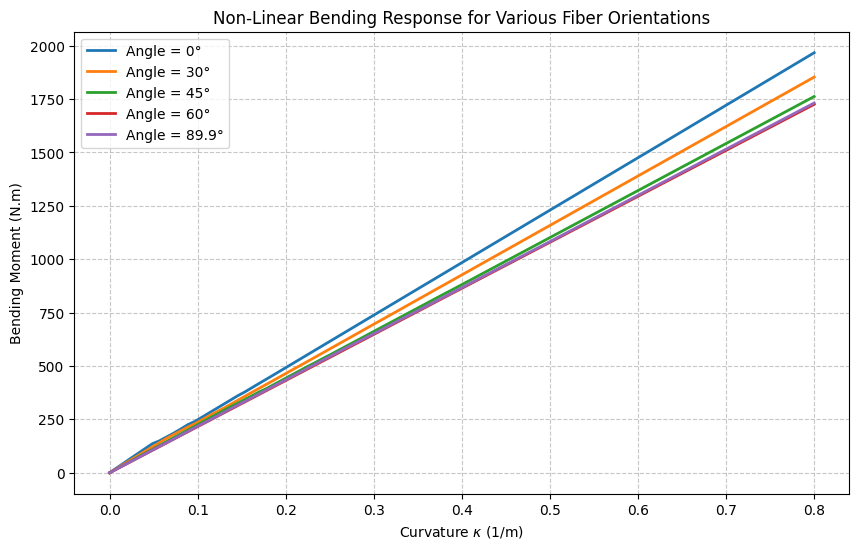

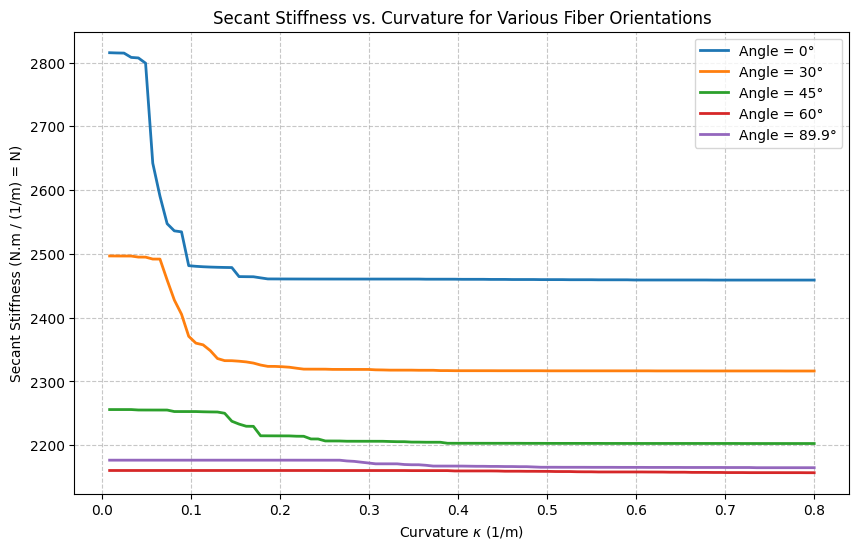

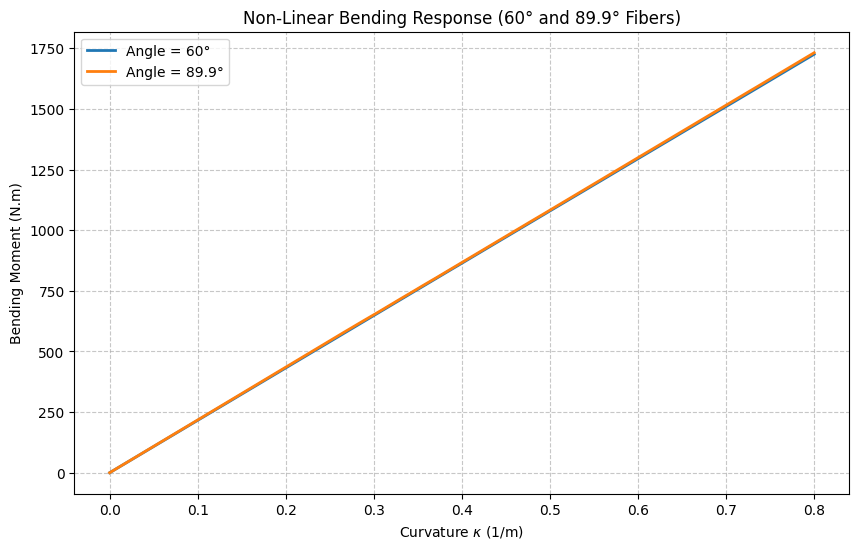

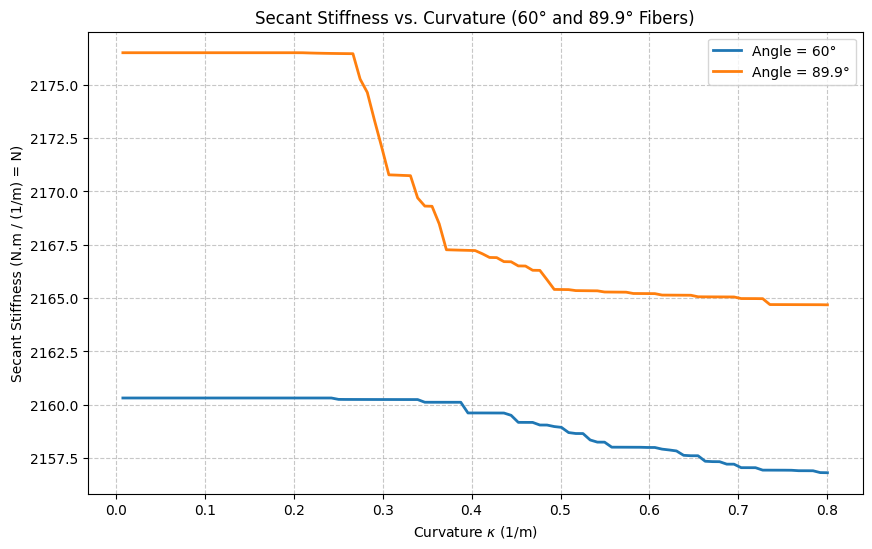

In [ ]:
# ==========================================
# FINAL STEP: MULTIPLE FIBER ORIENTATIONS (MERGED)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# We test a spread of angles from 0 to almost 90.
angles_to_test = [0, 30, 45, 60, 89.9]
num_fibers_test = 10

# Dictionaries to store results so we only run the solver ONCE per angle
all_kappas = {}
all_moments = {}
all_stiffness_kappas = {}
all_stiffness = {}

print("Starting combined simulation for Bending Moment and Secant Stiffness...")

for angle in angles_to_test:
    print(f"\n--- Simulating Fiber Orientation: {angle}° ---")

    # 1. Generate Fibers for this specific angle
    fibers_current = generate_fibers(L, angle, num_fibers=num_fibers_test)

    # 2. Find the mesh cuts
    cuts_current = find_cut_elements(nodes, cst_elements, fibers_current)

    # 3. Run the Non-Linear Bending Solver
    kappas_res, moments_res, _ = solve_nonlinear_bending_NR(
        nodes, cst_elements, cuts_current, L, thickness, V_f,
        E_m, nu_m, E_f, f_t, G_f, max_kappa, num_steps
    )

    # 4. Store Moment results for plotting later
    all_kappas[angle] = kappas_res
    all_moments[angle] = moments_res

    # 5. Calculate and store Secant Stiffness
    # Exclude kappa = 0 to avoid division by zero
    valid_kappas = np.array(kappas_res[1:])
    valid_moments = np.array(moments_res[1:])
    secant_stiffness = np.divide(valid_moments, valid_kappas, where=valid_kappas!=0)

    all_stiffness_kappas[angle] = valid_kappas
    all_stiffness[angle] = secant_stiffness

print("\nSimulations complete. Generating plots...")

# ------------------------------------------
# PLOT 1: Bending Moment vs. Curvature
# ------------------------------------------
plt.figure(figsize=(10, 6))
for angle in angles_to_test:
    plt.plot(all_kappas[angle], all_moments[angle], linewidth=2, label=f'Angle = {angle}°')

plt.xlabel(r'Curvature $\kappa$ (1/m)')
plt.ylabel('Bending Moment (N.m)')
plt.title('Non-Linear Bending Response for Various Fiber Orientations')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# ------------------------------------------
# PLOT 2: Secant Stiffness vs. Curvature
# ------------------------------------------
plt.figure(figsize=(10, 6))
for angle in angles_to_test:
    plt.plot(all_stiffness_kappas[angle], all_stiffness[angle], linewidth=2, label=f'Angle = {angle}°')

plt.xlabel(r'Curvature $\kappa$ (1/m)')
plt.ylabel('Secant Stiffness (N.m / (1/m) = N)')
plt.title('Secant Stiffness vs. Curvature for Various Fiber Orientations')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# ------------------------------------------
# PLOT 3: Bending Moment vs. Curvature (60° and 70° ONLY)
# ------------------------------------------
plt.figure(figsize=(10, 6))
angles_subset = [60, 89.9]

for angle in angles_subset:
    # We check if the angle is in our dictionary just to be safe
    if angle in all_kappas:
        plt.plot(all_kappas[angle], all_moments[angle], linewidth=2, label=f'Angle = {angle}°')

plt.xlabel(r'Curvature $\kappa$ (1/m)')
plt.ylabel('Bending Moment (N.m)')
plt.title('Non-Linear Bending Response (60° and 89.9° Fibers)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# ------------------------------------------
# PLOT 4: Secant Stiffness vs. Curvature (60° and 70° ONLY)
# ------------------------------------------
plt.figure(figsize=(10, 6))

for angle in angles_subset:
    if angle in all_stiffness_kappas:
        plt.plot(all_stiffness_kappas[angle], all_stiffness[angle], linewidth=2, label=f'Angle = {angle}°')

plt.xlabel(r'Curvature $\kappa$ (1/m)')
plt.ylabel('Secant Stiffness (N.m / (1/m) = N)')
plt.title('Secant Stiffness vs. Curvature (60° and 89.9° Fibers)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


--- Testing Gmsh Mesh Resolution (lc = 0.015) ---
Step  1 | Kappa: 0.008 | Moment:   24.6 N.m | Broken: 3/98 | Iters: 3
Step  2 | Kappa: 0.016 | Moment:   49.1 N.m | Broken: 3/98 | Iters: 3
Step  3 | Kappa: 0.024 | Moment:   73.7 N.m | Broken: 3/98 | Iters: 3
Step  4 | Kappa: 0.032 | Moment:   98.3 N.m | Broken: 3/98 | Iters: 3
Step  5 | Kappa: 0.040 | Moment:  122.8 N.m | Broken: 3/98 | Iters: 3
Step  6 | Kappa: 0.048 | Moment:  140.3 N.m | Broken: 11/98 | Iters: 5
Step  7 | Kappa: 0.057 | Moment:  163.7 N.m | Broken: 11/98 | Iters: 4
Step  8 | Kappa: 0.065 | Moment:  171.9 N.m | Broken: 23/98 | Iters: 4
Step  9 | Kappa: 0.073 | Moment:  193.4 N.m | Broken: 23/98 | Iters: 4
Step 10 | Kappa: 0.081 | Moment:  214.8 N.m | Broken: 23/98 | Iters: 3
Step 11 | Kappa: 0.089 | Moment:  230.8 N.m | Broken: 35/98 | Iters: 6
Step 12 | Kappa: 0.097 | Moment:  251.7 N.m | Broken: 35/98 | Iters: 4
Step 13 | Kappa: 0.105 | Moment:  272.6 N.m | Broken: 35/98 | Iters: 5
Step 14 | Kappa: 0.113 | Moment

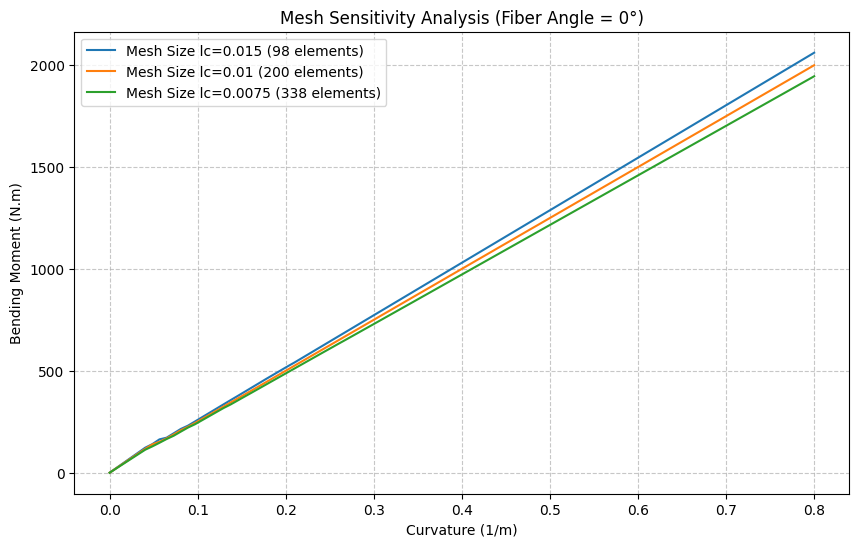

In [ ]:
import matplotlib.pyplot as plt

# Characteristic lengths (lc) to test (smaller = finer mesh)
# 0.01 is roughly equivalent to a 10x10 grid
mesh_sizes = [0.015, 0.010, 0.0075]
angle_study = 0 # Testing 0-degree fibers

plt.figure(figsize=(10, 6))

for lc in mesh_sizes:
    print(f"\n--- Testing Gmsh Mesh Resolution (lc = {lc}) ---")

    # 1. Re-generate mesh using Gmsh
    nodes_s, elements_s = generate_gmsh_matrix_mesh(L, lc)

    # 2. Re-generate fibers and find cuts
    fibers_s = generate_fibers(L, angle_study, num_fibers=12)
    cuts_s = find_cut_elements(nodes_s, elements_s, fibers_s)

    # 3. Run non-linear solver
    # Using fewer steps (40) for speed in this sensitivity study
    k_study, m_study, _ = solve_nonlinear_bending_NR(
        nodes_s, elements_s, cuts_s, L, thickness, V_f,
        E_m, nu_m, E_f, f_t, G_f, max_kappa, num_steps
    )

    plt.plot(k_study, m_study, label=f'Mesh Size lc={lc} ({len(elements_s)} elements)')

plt.xlabel('Curvature (1/m)')
plt.ylabel('Bending Moment (N.m)')
plt.title(f'Mesh Sensitivity Analysis (Fiber Angle = {angle_study}°)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()